<a href="https://colab.research.google.com/github/JDVAR7/TelecomX2-LAD/blob/main/TelecomX2_LAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Reto Telecom2**

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [63]:
df = pd.read_csv('/content/datos_tratados.csv')

In [64]:
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


## **Pre-procesamiento**

### Remosión de columnas irrelevantes

In [66]:
df= df.drop(columns=['CustomerID'])

In [67]:
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


#### Con el animo de simplificar los datos a fin de evitar un sobre-entreamiento, agrupamos el No internet service con No

In [68]:
colms_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in colms_fix:
  df[col] = df[col].replace('No internet service', 'No')

### Se verifican los valores nulos

In [69]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Realizamos una correlación

A efecto de buscar las variables que afectan a otra

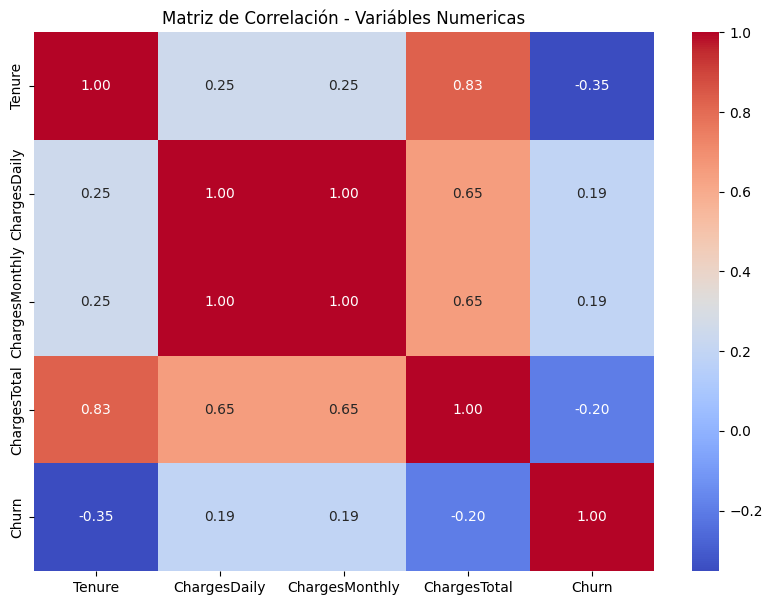

In [70]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])
df_numeric['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

correlation_matrix = df_numeric.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

#### Las columnas ChargesDaily, muy relacionada con ChargeMontly, y ChargesTotal, está muy correlacionadas con la columna Tenure, así como su reflejo en Churn, por lo que se disponen para su eliminación.

In [71]:
df = df.drop(columns=['ChargesDaily', 'ChargesTotal'])

###  Analisis de churn por categoria (variables categoricas)



#### Seleccionar variables categoricas

In [72]:
categorical_colms = df.select_dtypes(include=['object']).columns
categorical_colms = categorical_colms.drop('Churn')
categorical_colms

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

#### Tabla de proporción por categoria

In [73]:
for col in categorical_colms:
    print(f"\n♠ Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


♠ Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



♠ Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



♠ Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



♠ Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



♠ Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


#### Tenemos un metodo frente al cual se puede evaluar la importancia de una estancia 'Churn' a efcto de no desgartar tanto tiempo en un analisis de columna por columna - Qui-cuadrado (Chi-Square Test)

In [74]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_Rank = df.copy()

# Convertir Churn a binario
df_Rank["Churn"] = df_Rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_colms = df_Rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
LE = LabelEncoder()
for col in categorical_colms:
    df_Rank[col] = LE.fit_transform(df_Rank[col])

# Separar X e y
X_cat = df_Rank[categorical_colms]
y = df_Rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_colms,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [75]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)



✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


#### Encontrando a Gender así como PhoneService como variables menos relacionadas en el contexto de analisis a realizar...

In [76]:
df = df.drop(columns=["Gender", "PhoneService"])

## Split

In [77]:
X = df.drop('Churn', axis=1)
y = df['Churn']

### 2. split

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=43)

### 3. One-hot Encoding

In [79]:
# Aplicar One-Hot Encoding en treno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treno y teste tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [80]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3799,52,80.20,False,False,False,True,True,False,False,True,False,False,False,False,True,False,True,False,False,True
1936,23,88.45,True,True,True,False,True,False,False,True,True,False,False,True,False,False,True,False,False,False
180,1,95.45,False,False,False,True,True,False,False,False,False,False,True,True,False,False,True,False,True,False
4912,65,84.85,False,False,False,False,False,False,True,True,True,True,True,True,False,True,True,False,False,False
2991,9,64.95,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,True


In [81]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 3799 to 4888
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 4930 non-null   int64  
 1   ChargesMonthly                         4930 non-null   float64
 2   SeniorCitizen_Yes                      4930 non-null   bool   
 3   Partner_Yes                            4930 non-null   bool   
 4   Dependents_Yes                         4930 non-null   bool   
 5   MultipleLines_Yes                      4930 non-null   bool   
 6   InternetService_Fiber optic            4930 non-null   bool   
 7   InternetService_No                     4930 non-null   bool   
 8   OnlineSecurity_Yes                     4930 non-null   bool   
 9   OnlineBackup_Yes                       4930 non-null   bool   
 10  DeviceProtection_Yes                   4930 non-null   bool   
 11  TechSu

#### 4. Verificando Desvalance

In [82]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.46856
Yes,26.53144


In [83]:
!pip install imbalanced-learn

In [84]:
from imblearn.over_sampling import SMOTE

In [85]:
sm = SMOTE(random_state=43)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [143]:
print('Antes de SMOTE:')
print(y_train.value_counts())

print('\nDespués de SMOTE:')
print(y_train_res.value_counts())

Antes de SMOTE:
Churn
No     3622
Yes    1308
Name: count, dtype: int64

Después de SMOTE:
Churn
No     3622
Yes    3622
Name: count, dtype: int64


In [87]:
from sklearn.preprocessing import StandardScaler

In [88]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

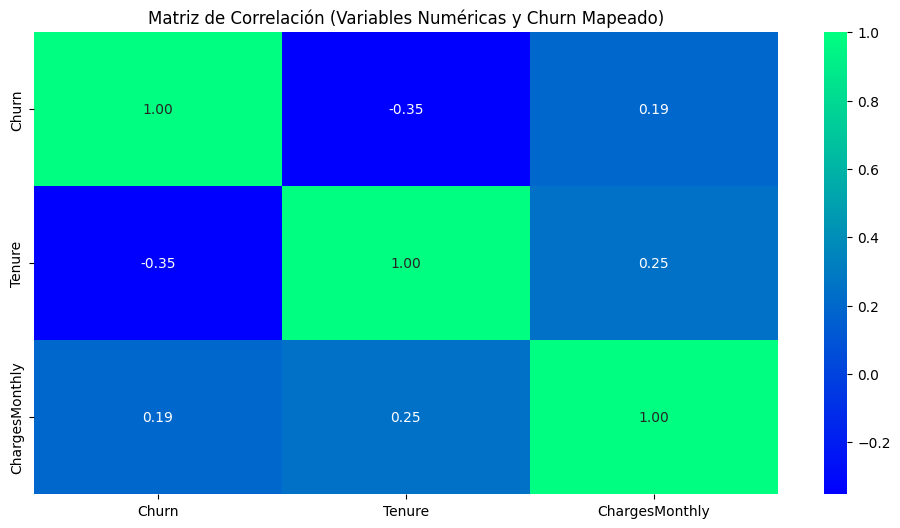

In [89]:
plt.figure(figsize=(12,6))

temp_df_corr = df.copy()
temp_df_corr['Churn'] = temp_df_corr['Churn'].map({'Yes': 1, 'No': 0})
correlation = temp_df_corr.select_dtypes(include=['number']).corr()

sns.heatmap(correlation, cmap='winter', annot=True, fmt=".2f")
plt.title('Matriz de Correlación (Variables Numéricas y Churn Mapeado)')
plt.show()

### Creamos la matriz de correlación

In [90]:
df_train = X_train.copy()
df_train['Churn'] = y_train

In [91]:
corr = X_train.copy()
corr['Churn'] = y_train

corr = corr.corr(numeric_only=True)

In [92]:
df_train_numeric_churn = df_train.copy()
df_train_numeric_churn['Churn'] = df_train_numeric_churn['Churn'].map({'Yes': 1, 'No': 0})

# Recalculamos la correlación de la matriz incluyendo la columna númerica del Churn
corr_with_churn = df_train_numeric_churn.corr()

corr_churn = corr_with_churn['Churn'].drop('Churn').sort_values()

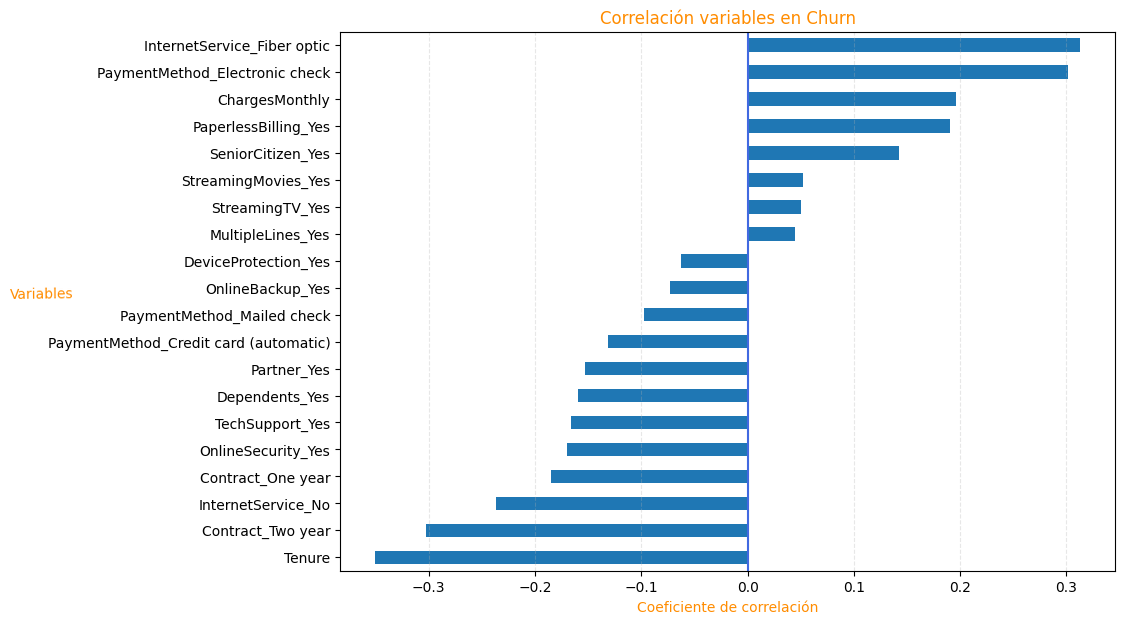

In [144]:
plt.figure(figsize=(10,7))
corr_churn.plot(kind='barh')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.title('Correlación variables en Churn', color='darkorange')
plt.xlabel('Coeficiente de correlación', color='darkorange')
plt.ylabel('Variables', color='darkorange', rotation=0.7)

plt.axvline(0, color='royalblue')
plt.show()

###### De acuerdo con los parametros evaluados, podemos observar el potencial de riesgo frente a la perdida de suscriptores en la fibra optica, los adultos mayores, cargos mensuales altos o metodos de pago.

#### Graficos con relación a la variable objetivo (Churn)

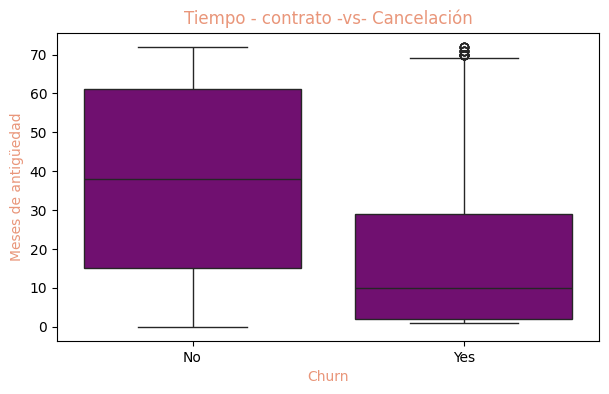

In [145]:
plt.figure(figsize=(7,4))

sns.boxplot(x='Churn', y='Tenure', data=df, color="purple")

plt.title('Tiempo - contrato -vs- Cancelación', color ='darksalmon')
plt.xlabel('Churn', color ='darksalmon')
plt.ylabel('Meses de antigüedad', color ='darksalmon')

plt.show()

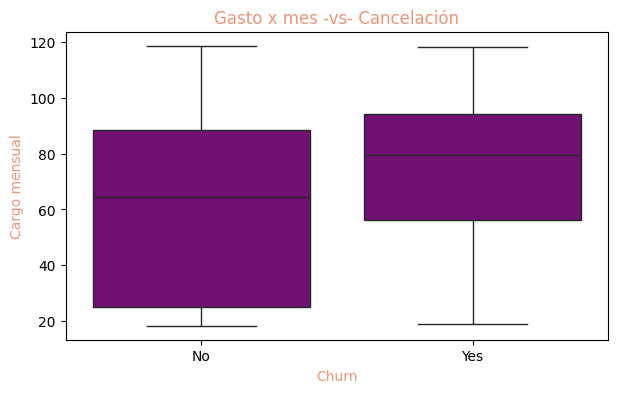

In [146]:
plt.figure(figsize=(7,4))

sns.boxplot(x='Churn', y='ChargesMonthly', data=df, color="purple")

plt.title('Gasto x mes -vs- Cancelación', color ='darksalmon')
plt.xlabel('Churn', color ='darksalmon')
plt.ylabel('Cargo mensual', color ='darksalmon')

plt.show()

###### En vista de los resultados, parece que los clientes que se encuentran más cercanos a la cancelación de los servicios, no resultan ser usuarios antiguos, así como los clientes con cargos más elevados, son las más propensos a cancelar sus suscripciones.

### Entrenamiento

#### Modelo 1 - Regresión logistica

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

Log_model = LogisticRegression(max_iter=1000)
Log_model.fit(X_train, y_train)

y_pred_Log_normal = Log_model.predict(X_test)

print('Regresion logistica')
print(classification_report(y_test, y_pred_Log_normal))

Regresion logistica
              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1552
         Yes       0.64      0.54      0.58       561

    accuracy                           0.80      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.79      0.80      0.79      2113



#### Modelo 2 - Random Forest

In [148]:
from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier(random_state=43)
RF_model.fit(X_train, y_train)

y_pred_RF = RF_model.predict(X_test)

print('Random Forest')
print(classification_report(y_test, y_pred_RF))

Random Forest
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1552
         Yes       0.62      0.50      0.55       561

    accuracy                           0.79      2113
   macro avg       0.72      0.69      0.71      2113
weighted avg       0.77      0.79      0.78      2113



In [149]:
from sklearn.linear_model import LogisticRegression

Log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
Log_model.fit(X_train, y_train)

y_pred_Log = Log_model.predict(X_test)

print(classification_report(y_test, y_pred_Log))

              precision    recall  f1-score   support

          No       0.90      0.72      0.80      1552
         Yes       0.50      0.79      0.61       561

    accuracy                           0.74      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.80      0.74      0.75      2113



### Modelo 3. Arbol de Decisión

In [115]:
from sklearn.tree import DecisionTreeClassifier

In [118]:
model_AD = DecisionTreeClassifier(random_state=43)

In [119]:
model_AD.fit(X_train, y_train)

DecisionTreeClassifier(random_state=43)

In [122]:
y_pred_AD = model_AD.predict(X_test)

In [150]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy:', accuracy_score(y_test, y_pred_AD))
print('Precision:', precision_score(y_test, y_pred_AD, pos_label='Yes'))
print('Recall:', recall_score(y_test, y_pred_AD, pos_label='Yes'))
print('F1 Score:', f1_score(y_test, y_pred_AD, pos_label='Yes'))

Accuracy: 0.7269285376242309
Precision: 0.4866666666666667
Recall: 0.5204991087344029
F1 Score: 0.5030146425495263


In [151]:
print('\nReporte de clasificación:\n')
print(classification_report(y_test, y_pred_AD))


Reporte de clasificación:

              precision    recall  f1-score   support

          No       0.82      0.80      0.81      1552
         Yes       0.49      0.52      0.50       561

    accuracy                           0.73      2113
   macro avg       0.65      0.66      0.66      2113
weighted avg       0.73      0.73      0.73      2113



## Evaluación

#### Evaluación de todos los modelos

In [131]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'Árbol de decisión'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_Log_normal),
        accuracy_score(y_test, y_pred_RF),
        accuracy_score(y_test, y_pred_AD)
    ],
    'Precision': [
        precision_score(y_test, y_pred_Log_normal, pos_label='Yes'),
        precision_score(y_test, y_pred_RF, pos_label='Yes'),
        precision_score(y_test, y_pred_AD, pos_label='Yes')
    ],
    'Recall': [
        recall_score(y_test, y_pred_Log_normal, pos_label='Yes'),
        recall_score(y_test, y_pred_RF, pos_label='Yes'),
        recall_score(y_test, y_pred_AD, pos_label='Yes')

    ],
    'F1 Score': [
        f1_score(y_test, y_pred_Log_normal, pos_label='Yes'),
        f1_score(y_test, y_pred_RF, pos_label='Yes'),
        f1_score(y_test, y_pred_AD, pos_label='Yes')

    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Regresión Logística,0.795078,0.635021,0.536542,0.581643
1,Random Forest,0.785140,0.618102,0.499109,0.552268
2,Árbol de decisión,0.726929,0.486667,0.520499,0.503015


In [152]:
results.sort_values(by='Recall', ascending=False)

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Regresión Logística,0.795078,0.635021,0.536542,0.581643
2,Árbol de decisión,0.726929,0.486667,0.520499,0.503015
1,Random Forest,0.785140,0.618102,0.499109,0.552268


###### Luego de la evaluación tripartita, a fin de predecir el 'Churn' y su comportamiento podmeos observar que la Regresión Logistica aparece como el modelo más equilibrado para dar con los parametros más acordes en nuestyro proceso

In [137]:
from sklearn.linear_model import LogisticRegression

modelo_final = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=43)

modelo_final.fit(X_train, y_train)

y_pred_final = modelo_final.predict(X_test)

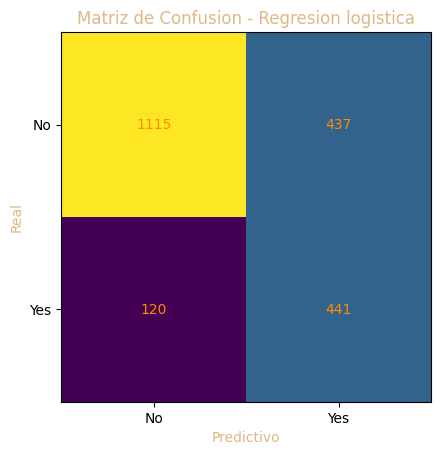

In [142]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred_final)

# Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de Confusion - Regresion logistica', color='burlywood')
plt.xlabel('Predictivo', color='burlywood')
plt.ylabel('Real', color='burlywood')


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='darkorange')

plt.xticks([0,1], ['No', 'Yes'])
plt.yticks([0,1], ['No', 'Yes'])

plt.show()

In [140]:
coeficientes = pd.DataFrame({'Variable': X_train.columns,'Coeficiente': modelo_final.coef_[0]})

In [153]:
coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

coeficientes.head(13)

,Variable,Coeficiente
6,InternetService_Fiber optic,1.349876
13,StreamingMovies_Yes,0.448184
12,StreamingTV_Yes,0.427360
18,PaymentMethod_Electronic check,0.358125
5,MultipleLines_Yes,0.355046
16,PaperlessBilling_Yes,0.262972
2,SeniorCitizen_Yes,0.207707
10,DeviceProtection_Yes,0.081083
9,OnlineBackup_Yes,0.031868
19,PaymentMethod_Mailed check,0.005621


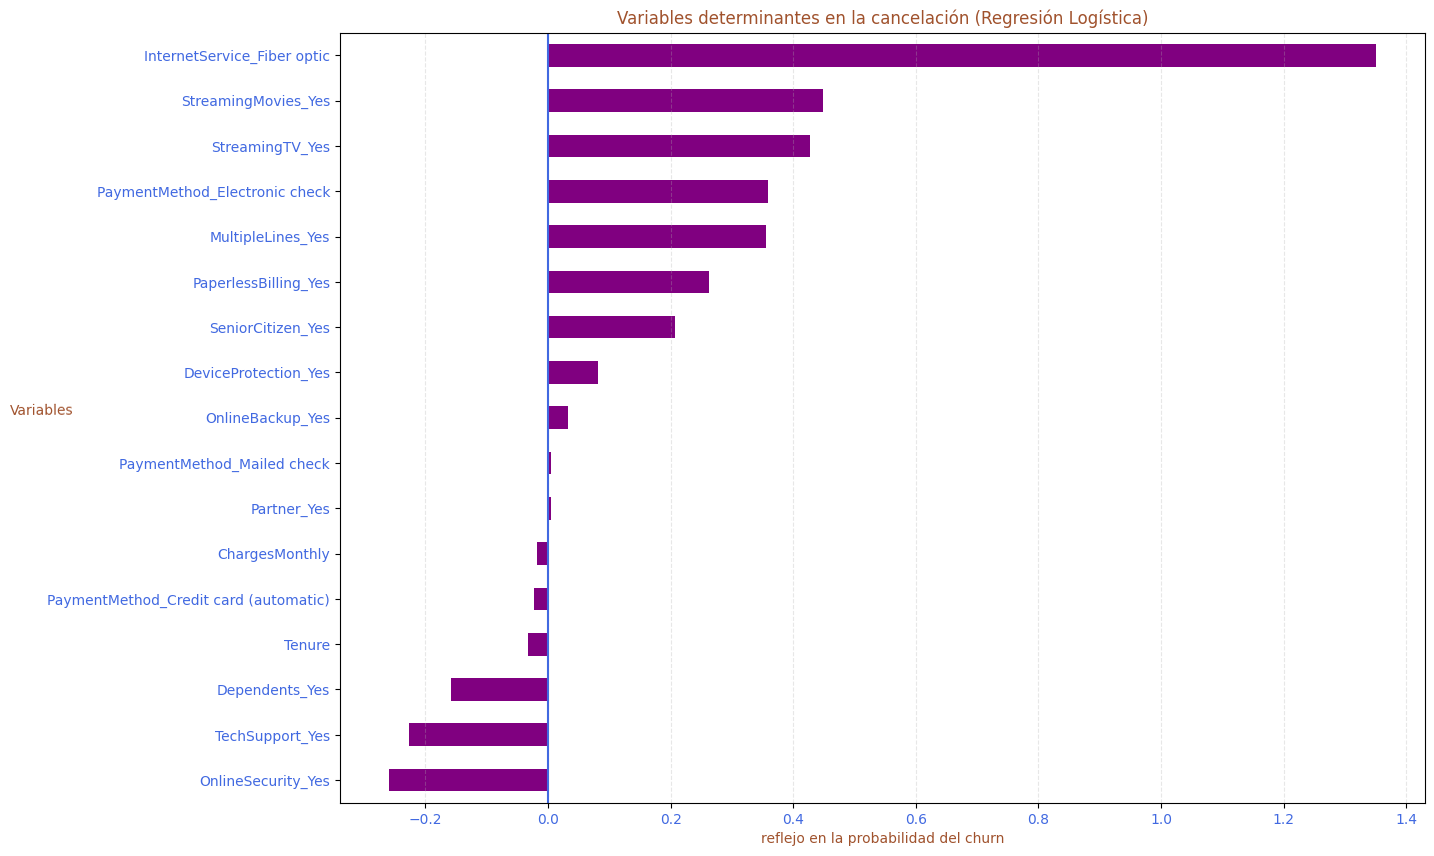

In [165]:
fig, ax = plt.subplots(figsize=(14,10))

coeficientes.set_index('Variable').head(17)['Coeficiente'] \
    .sort_values() \
    .plot(kind='barh', color="purple", ax=ax) # Plot on the created ax

ax.grid(axis='x', linestyle='--', alpha=0.3)

ax.set_title('Variables determinantes en la cancelación (Regresión Logística)', color='sienna')
ax.set_xlabel('reflejo en la probabilidad del churn', color='sienna')
ax.set_ylabel('Variables', color='sienna', rotation=0.3)

for tick_label in ax.get_xticklabels():
    tick_label.set_color('royalblue')
for tick_label in ax.get_yticklabels():
    tick_label.set_color('royalblue')

ax.axvline(0, color='royalblue')
plt.show()

### **Evaluación e Importancia**

##### **Respecto del alcance de los diferentes modelos:**

Pudimos comprobar que en la evaluación de los diferentes modelos, en cada uno de ellos, se pudo reflejar un porcentaje de deserción criticamente alto en los primeros meses de integración de los usuarios, de modo contrario es más facil o adaptable la permanencia d eclientes más antiguos y que se han estabilizado ante los metodos y las diferentes metricas d ela empresa.

La cancelación de clientes podría impactar directamente en los ingresos de la empresa, por lo que diseñar estrategias de satisfacción para nuevos clientes debe ser tan importante como la adaptabilidad o estabilidad d elos clientes más duraderos.


##### Regresión Logística

De acuerdo con la implementación de nuestros sistemas de evaluación, pudimos observar como variables más importantes:

Antigüedad del cliente
Cargo total
Cargo mensual
Tipo de contrato
Servicio de internet

Esto confirma que el tiempo de permanencia puede ser determinante, sobretodo en clientes nuevos.

A parte de lo anterior, los montos totales y cargos mensuales tambien representan una curva importante para la deserción y fuga masiva de clientes por parte de la empresa

Los Principales Factores que Influyen en la Cancelación:

    -Clientes nuevos tienen mayor probabilidad de cancelar
    -Contratos mensuales presentan mayor riesgo.
    -Métodos de pago manuales muestran mayor evasión.
    -Cargos mensuales elevados aumentan la probabilidad de abandono.

Frente a estas mayores posibilidades de perdidas en la fidelización y sostenibilidad de la clientela, queremos postular algunas estrategias de retención a evaluar:

1️⃣ Implementar campañas de incentivos que faciliten la fidelización del cliente en los primeros meses de suscripción.

2️⃣ Procurar contratos de largo plazo con llamativos descuentos.

3️⃣ Generar beneficios y/o estatus corporativo a clientes con contrato anual a fin insentivar dichos planes por encima de los planes mensuales.

4️⃣ compensar o rediseñar estructura de precios en clientes con alta factura mensual.

5️⃣ implementar alertas predictivas usando el modelo entrenado.

### **Conclusiones**


##### La evaluación realizada por nuestros expertos nos ha permitido identificar y profundizar en ciscunstancias claras asociadas a la cancelación de servicios, así como validar modelos predictivos capaces de modelar las diferentes instancias de deserción e insatisfacción del usuario. La (regresión logística) o modelo estimatorio de procesos, reflejó un importante equilibrio a tener presente para detectar zonas de alto riesgo frente a la posibilidad de fuga de clientes, para así poder evaluar estrategias de sostenibilidad y afianzamiento de una comunidad más satisfecha, como enamorada de la empresa. Estos resultados permiten evaluar estrategias de retención enfocadas en clientes nuevos, contratos flexibles y servicios de valor agregado, para cada uno de los usuarios, aplicando frentes de atracción además de su fidelización.
